In [1]:
#import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

In [2]:
#1 import database / data

In [3]:
conn = sqlite3.connect('customer_churn.db')

sql_query = """
        SELECT name
        FROM sqlite_master
        WHERE type='table'
"""

tables = pd.read_sql(sql_query,conn)

# create dataframe for each table
for table_name in tables['name']:
    df = pd.read_sql(f"SELECT * FROM {table_name}",conn)
    globals()[f"df_{table_name}"] = df
    print(f"Created dataframe: df_{table_name}")

conn.close()

Created dataframe: df_db_customer
Created dataframe: df_db_subscription
Created dataframe: df_db_support


In [4]:
# print table names and column names
conn = sqlite3.connect('customer_churn.db')

for table_name in tables['name']:
    print(f"\nTable Name: {table_name}")
    
    # get column information
    columns_query = f"PRAGMA table_info({table_name});"
    columns = pd.read_sql(columns_query,conn)
    print("Columns: ")
    print(columns['name'].tolist())

# close connection
conn.close()


Table Name: db_customer
Columns: 
['customerid', 'name', 'country', 'state', 'gender', 'dob', 'interests', 'pincode']

Table Name: db_subscription
Columns: 
['customerid', 'subscription_start_date', 'subscription_type', 'renewal_date', 'plan_type', 'contract_type', 'cancellation_date', 'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score']

Table Name: db_support
Columns: 
['customerid', 'complaint_date', 'escalations', 'csat_score', 'col_1', 'comment']


In [5]:
df_db_customer.head()

,customerid,name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00,travel,None
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00,NaN,None
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00,movie,None
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00,NaN,None
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00,drama,None


In [6]:
df_db_customer.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerid  21 non-null     str   
 1   name        21 non-null     str   
 2   country     18 non-null     str   
 3   state       21 non-null     str   
 4   gender      21 non-null     str   
 5   dob         21 non-null     str   
 6   interests   4 non-null      str   
 7   pincode     0 non-null      object
dtypes: object(1), str(7)
memory usage: 1.4+ KB


In [7]:
df_db_customer.tail()

,customerid,name,country,state,gender,dob,interests,pincode
16,0020-JDNXP,rikim,India,Meghalaya,Female,1994-08-19 00:00:00,NaN,None
17,0021-IKXGC,vishakha,India,Rajasthan,Female,2000-09-02 00:00:00,NaN,None
18,0022-TCJCI,raghvendra,India,Telangana,Male,1983-12-30 00:00:00,NaN,None
19,0023-HGHWL,rishabh,India,Uttar Pradesh,Men,1991-05-14 00:00:00,NaN,None
20,0023-UYUPN,sudevi,India,Maharashtra,Women,1977-10-06 00:00:00,NaN,None


In [8]:
#1 Clean Table - db_customer table

# Rename Column - name-> customer_name
# Drop Column - interests and pincode
# change data type - dob
# Data standardization - gender
# fix missing values - country

In [9]:
#1.1 Rename Column - name
df_db_customer.rename(columns={'name':'customer_name'},inplace=True)
df_db_customer

,customerid,customer_name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00,travel,None
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00,NaN,None
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00,movie,None
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00,NaN,None
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00,drama,None
5,0013-MHZWF,durga,NaN,Delhi,Women,1988-12-10 00:00:00,NaN,None
6,0013-SMEOE,mina,India,Meghalaya,Female,1976-09-21 00:00:00,NaN,None
7,0014-BMAQU,madan,India,Rajasthan,Male,1999-03-14 00:00:00,NaN,None
8,0015-UOCOJ,maya,NaN,Kathmandu,Women,1985-07-07 00:00:00,NaN,None
9,0016-QLJIS,arjun,Nepal,Kathmandu,Male,1993-10-29 00:00:00,NaN,None


In [10]:
#1.2 Drop Column - interests and pincode

# df_db_customer.drop(df_db_customer.columns[-2:],axis=1)  solution 1
# df_db_customer.drop(df_db_customer.columns[6:],axis=1)   solution 2
df_db_customer.drop(columns=['interests','pincode'],inplace=True) 
df_db_customer


,customerid,customer_name,country,state,gender,dob
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00
5,0013-MHZWF,durga,NaN,Delhi,Women,1988-12-10 00:00:00
6,0013-SMEOE,mina,India,Meghalaya,Female,1976-09-21 00:00:00
7,0014-BMAQU,madan,India,Rajasthan,Male,1999-03-14 00:00:00
8,0015-UOCOJ,maya,NaN,Kathmandu,Women,1985-07-07 00:00:00
9,0016-QLJIS,arjun,Nepal,Kathmandu,Male,1993-10-29 00:00:00


In [11]:
#1.3 Change data type - dob
df_db_customer['dob'] = pd.to_datetime(df_db_customer['dob'])

In [12]:
df_db_customer.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   customerid     21 non-null     str           
 1   customer_name  21 non-null     str           
 2   country        18 non-null     str           
 3   state          21 non-null     str           
 4   gender         21 non-null     str           
 5   dob            21 non-null     datetime64[us]
dtypes: datetime64[us](1), str(5)
memory usage: 1.1 KB


In [13]:
#1.4 Data standardization - gender

# df_db_customer['gender'].unique()

df_db_customer['gender'] = df_db_customer['gender'].replace({'Men':'Male','Women':'Female'})
df_db_customer

,customerid,customer_name,country,state,gender,dob
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05
5,0013-MHZWF,durga,NaN,Delhi,Female,1988-12-10
6,0013-SMEOE,mina,India,Meghalaya,Female,1976-09-21
7,0014-BMAQU,madan,India,Rajasthan,Male,1999-03-14
8,0015-UOCOJ,maya,NaN,Kathmandu,Female,1985-07-07
9,0016-QLJIS,arjun,Nepal,Kathmandu,Male,1993-10-29


In [14]:
#1.5 fix missing values - country

# df_db_customer['country'].fillna('Empty')          - fillna()
# df_db_customer[df_db_customer['country'].isna()]   - isna()

# country and state - unique value pair
state_country_map = df_db_customer.dropna(subset=['country']).set_index('state')['country'].to_dict()

df_db_customer['country'] = df_db_customer['country'].fillna(df_db_customer['state'].map(state_country_map))


In [15]:
#2 Clean Table - db_subscription table

In [16]:
df_db_subscription.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customerid               21 non-null     str    
 1   subscription_start_date  21 non-null     str    
 2   subscription_type        21 non-null     str    
 3   renewal_date             21 non-null     str    
 4   plan_type                21 non-null     str    
 5   contract_type            21 non-null     str    
 6   cancellation_date        6 non-null      str    
 7   cancellation_reason      6 non-null      str    
 8   monthly_charges          21 non-null     float64
 9   cltv                     21 non-null     int64  
 10  churn_score              21 non-null     int64  
dtypes: float64(1), int64(2), str(8)
memory usage: 1.9 KB


In [17]:
#2.1 change data type 
date_type = ['subscription_start_date','renewal_date','cancellation_date']
df_db_subscription[date_type] = df_db_subscription[date_type].apply(pd.to_datetime,)

In [18]:
df_db_subscription.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   customerid               21 non-null     str           
 1   subscription_start_date  21 non-null     datetime64[us]
 2   subscription_type        21 non-null     str           
 3   renewal_date             21 non-null     datetime64[us]
 4   plan_type                21 non-null     str           
 5   contract_type            21 non-null     str           
 6   cancellation_date        6 non-null      datetime64[us]
 7   cancellation_reason      6 non-null      str           
 8   monthly_charges          21 non-null     float64       
 9   cltv                     21 non-null     int64         
 10  churn_score              21 non-null     int64         
dtypes: datetime64[us](3), float64(1), int64(2), str(5)
memory usage: 1.9 KB


In [19]:
#3 Clean Table - db_support

In [20]:
df_db_support.info()

<class 'pandas.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customerid      9 non-null      str   
 1   complaint_date  9 non-null      str   
 2   escalations     9 non-null      str   
 3   csat_score      9 non-null      int64 
 4   col_1           0 non-null      object
 5   comment         4 non-null      str   
dtypes: int64(1), object(1), str(4)
memory usage: 564.0+ bytes


In [21]:
#3.1 remove column -  col_1,comment
df_db_support.head()

,customerid,complaint_date,escalations,csat_score,col_1,comment
0,0003-MKNFE,2024-08-28 00:00:00,N,60,None,service issue
1,0003-MKNFE,2024-08-28 00:00:00,Y,10,None,demaned refund
2,0013-EXCHZ,2024-01-20 00:00:00,Y,20,None,NaN
3,0013-MHZWF,2025-03-18 00:00:00,N,90,None,guidance to renew
4,0013-SMEOE,2024-11-01 00:00:00,N,30,None,NaN


In [22]:
df_db_support.info()

<class 'pandas.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customerid      9 non-null      str   
 1   complaint_date  9 non-null      str   
 2   escalations     9 non-null      str   
 3   csat_score      9 non-null      int64 
 4   col_1           0 non-null      object
 5   comment         4 non-null      str   
dtypes: int64(1), object(1), str(4)
memory usage: 564.0+ bytes


In [23]:
#3.2 remove column -  col_1,comment
df_db_support = df_db_support.drop(df_db_support.columns[-2:],axis=1)

In [24]:
df_db_support

,customerid,complaint_date,escalations,csat_score
0,0003-MKNFE,2024-08-28 00:00:00,N,60
1,0003-MKNFE,2024-08-28 00:00:00,Y,10
2,0013-EXCHZ,2024-01-20 00:00:00,Y,20
3,0013-MHZWF,2025-03-18 00:00:00,N,90
4,0013-SMEOE,2024-11-01 00:00:00,N,30
5,0017-IUDMW,2024-04-10 00:00:00,Y,25
6,0019-EFAEP,2024-09-27 00:00:00,Y,30
7,0022-TCJCI,2024-09-13 00:00:00,Y,10
8,0022-TCJCI,2024-09-14 00:00:00,N,90


In [25]:
#3.3 change data type - complaint_date
df_db_support['complaint_date'] = pd.to_datetime(df_db_support['complaint_date'])

In [26]:
df_db_support.info()

<class 'pandas.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   customerid      9 non-null      str           
 1   complaint_date  9 non-null      datetime64[us]
 2   escalations     9 non-null      str           
 3   csat_score      9 non-null      int64         
dtypes: datetime64[us](1), int64(1), str(2)
memory usage: 420.0 bytes


In [27]:
#3 Feacture Engineering and Data analysis  - column use krna,update karna,new values banana.

In [28]:
# create new column using existing column - churn flag
df_db_subscription['churn_flag'] = np.where(df_db_subscription['cancellation_date'].notna(),1,0)


In [29]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn_flag
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,12,0
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,NaN,6.99,210,34,0
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,NaN,22.99,1725,8,0
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88,1


In [30]:
# first fix support table duplicate and merge
df = (df_db_subscription
    .merge(df_db_customer, on='customerid',how='left')
    .merge(df_db_support, on='customerid',how='left'))


In [31]:
df.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn_flag,customer_name,country,state,gender,dob,complaint_date,escalations,csat_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,12,0,keshav,India,Maharashtra,Male,1982-04-12,NaT,NaN,NaN
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,N,60.0
2,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,Y,10.0
3,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,NaN,6.99,210,34,0,lalita,India,Delhi,Female,1978-02-15,NaT,NaN,NaN
4,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,NaN,22.99,1725,8,0,mohan,India,Nagaland,Male,2001-08-30,NaT,NaN,NaN


In [32]:
df.shape

(23, 20)

In [33]:
df_db_customer['customerid'].nunique()

21

In [34]:
df_db_subscription['customerid'].nunique()

21

In [35]:
df_db_support['customerid'].nunique()

7

In [36]:
df_db_support['customerid'].size

9

In [37]:
df_db_support

,customerid,complaint_date,escalations,csat_score
0,0003-MKNFE,2024-08-28,N,60
1,0003-MKNFE,2024-08-28,Y,10
2,0013-EXCHZ,2024-01-20,Y,20
3,0013-MHZWF,2025-03-18,N,90
4,0013-SMEOE,2024-11-01,N,30
5,0017-IUDMW,2024-04-10,Y,25
6,0019-EFAEP,2024-09-27,Y,30
7,0022-TCJCI,2024-09-13,Y,10
8,0022-TCJCI,2024-09-14,N,90


In [38]:
df_db_support['complaint_count'] = df_db_support.groupby('customerid')['customerid'].transform('count')

In [39]:
df_db_support

,customerid,complaint_date,escalations,csat_score,complaint_count
0,0003-MKNFE,2024-08-28,N,60,2
1,0003-MKNFE,2024-08-28,Y,10,2
2,0013-EXCHZ,2024-01-20,Y,20,1
3,0013-MHZWF,2025-03-18,N,90,1
4,0013-SMEOE,2024-11-01,N,30,1
5,0017-IUDMW,2024-04-10,Y,25,1
6,0019-EFAEP,2024-09-27,Y,30,1
7,0022-TCJCI,2024-09-13,Y,10,2
8,0022-TCJCI,2024-09-14,N,90,2


In [40]:
df_db_support = df_db_support.sort_values('complaint_date').drop_duplicates('customerid', keep='last')

In [41]:
df_db_support = df_db_support.drop(df_db_support.columns[-2],axis=1)

In [42]:
df_db_support

,customerid,complaint_date,escalations,complaint_count
2,0013-EXCHZ,2024-01-20,Y,1
5,0017-IUDMW,2024-04-10,Y,1
1,0003-MKNFE,2024-08-28,Y,2
8,0022-TCJCI,2024-09-14,N,2
6,0019-EFAEP,2024-09-27,Y,1
4,0013-SMEOE,2024-11-01,N,1
3,0013-MHZWF,2025-03-18,N,1


In [43]:
# merge diff
df = (df_db_subscription
    .merge(df_db_customer, on='customerid',how='left')
    .merge(df_db_support, on='customerid',how='left'))


In [44]:
df.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn_flag,customer_name,country,state,gender,dob,complaint_date,escalations,complaint_count
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,12,0,keshav,India,Maharashtra,Male,1982-04-12,NaT,NaN,NaN
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,Y,2.0
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,NaN,6.99,210,34,0,lalita,India,Delhi,Female,1978-02-15,NaT,NaN,NaN
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,NaN,22.99,1725,8,0,mohan,India,Nagaland,Male,2001-08-30,NaT,NaN,NaN
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88,1,mira,India,Delhi,Female,1990-05-05,2024-01-20,Y,1.0


In [45]:
df_db_subscription.shape

(21, 12)

In [46]:
df.shape

(21, 20)

In [47]:
df.to_csv('new_churn_data.csv',index=False)

In [48]:
# Data Analysis

In [49]:
#1 Churn Rate

In [50]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'complaint_count'],
      dtype='str')

In [51]:
churn_rate = df['churn_flag'].mean()*100
print("churn rate",round(churn_rate,2),"%")

churn rate 28.57 %


In [52]:
#2 Retension Rate

In [53]:
retension_rate = 100 - churn_rate
print("retension rate",round(retension_rate,2),'%')

retension rate 71.43 %


In [54]:
#3 churn by  plan type

In [55]:
churn_by_plan = df.groupby('plan_type')['churn_flag'].mean().mul(100).round(2).reset_index(name='churn_rate_pct')
print(churn_by_plan)

  plan_type  churn_rate_pct
0     Basic           60.00
1   Premium           14.29
2  Standard           22.22


In [56]:
#4 churn by state + sum(revenue)  & count of users 

In [57]:
df.groupby('state').agg(
    total_revenue=('monthly_charges', 'sum'),
    total_users=('customerid', 'count')
).reset_index()

,state,total_revenue,total_users
0,Delhi,52.96,4
1,Karnataka,20.98,2
2,Kathmandu,20.98,2
3,Maharashtra,50.97,3
4,Meghalaya,42.97,3
5,Nagaland,22.99,1
6,Rajasthan,36.98,2
7,Telangana,30.98,2
8,Uttar Pradesh,115.98,2


In [58]:
#5 churn by subscription type

In [59]:
df.groupby('subscription_type').agg(
    total_revenue=('monthly_charges', 'sum'),
    total_users=('customerid', 'count')
).reset_index()

,subscription_type,total_revenue,total_users
0,Organic,145.91,9
1,Paid,174.94,6
2,Refferal,74.94,6


In [60]:
#6 ARPU - average revenue per user

In [61]:
ARPU = df['monthly_charges'].mean()
print("ARPU=",round(ARPU,2))

ARPU= 18.85


In [62]:
#7 AVG Customer Turnue

In [63]:
# count of days users has  used out service: cancellation_date and current_date

today = pd.Timestamp.today()

df['tenure_days'] = np.where(
    df['cancellation_date'].notna(),
    
    (df['cancellation_date']-df['subscription_start_date']).dt.days,
        
    (today-df['subscription_start_date']).dt.days,
)


avg_tenure_days = df['tenure_days'].mean()
print('avg_tenure_days=',round(avg_tenure_days,0))

avg_tenure_days= 1491.0


In [64]:
#8 revenue at risk - revenue lost from churned users

In [65]:
revenue_risk = df.loc[df['churn_flag']==1,'monthly_charges'].sum()
print("Revenue_risk (Rs 'K')",revenue_risk)

Revenue_risk (Rs 'K') 73.94


In [66]:
#9 Esclation Rate

In [67]:
escaltion_rate = (df['escalations']=='Y').mean()*100
print("escalations: ",round(escaltion_rate,2))

escalations:  19.05


In [68]:
#10 average count per user

average_complaints = df['complaint_count'].sum()/df['customerid'].nunique()
print('average_complaint=',round(average_complaints,2))

average_complaint= 0.43


In [69]:
print(df[['escalations', 'churn_flag']].dtypes)
print(df['churn_flag'].unique())

escalations      str
churn_flag     int64
dtype: object
[0 1]


In [83]:
#11 Correlation Esclation  vs Churn
# df['escalations'] = np.where(df['escalations']=='Y',1,0)

corr_df = df[['escalations','churn_flag']].dropna()

correlation = corr_df['escalations'].corr(df['churn_flag'])
print('correlation between escaltion vs churn is = ',round(correlation,2))

correlation between escaltion vs churn is =  nan


In [71]:
# 12  churn risk = create a column using existing col
conditions = [
    (df['churn_score']<50),
    (df['churn_score']>=50) & (df['churn_score']<70),
    (df['churn_score']>70)
]
choice = ['low','med','high']

df['churn_risk'] = np.select(conditions,choice,default='unknown')

In [72]:
# visualization using matplotlib

In [73]:
df_visual = df.copy()

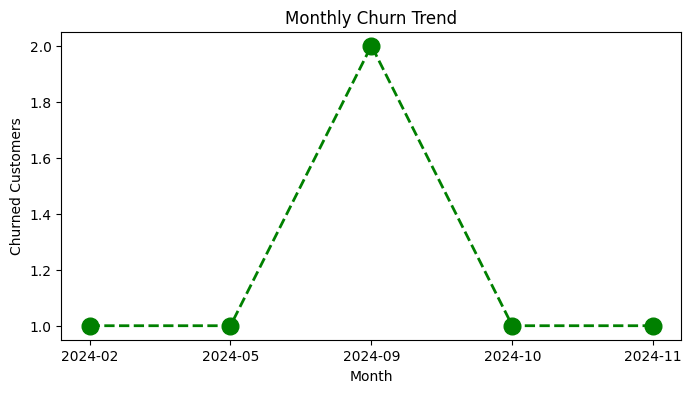

In [74]:
#1 Month Churn Trend (Time Series KPI)

df_visual['cancellation_month'] = df_visual['cancellation_date'].dt.to_period('M')

churn_trend = df_visual[df_visual['churn_flag']==1].groupby('cancellation_month').size()

plt.figure(figsize=(8,4))
plt.plot(churn_trend.index.astype(str),churn_trend.values,color='green', marker='o', linestyle='dashed',linewidth=2, markersize=12)

plt.title('Monthly Churn Trend')
plt.xlabel('Month')
plt.ylabel('Churned Customers')
plt.show()

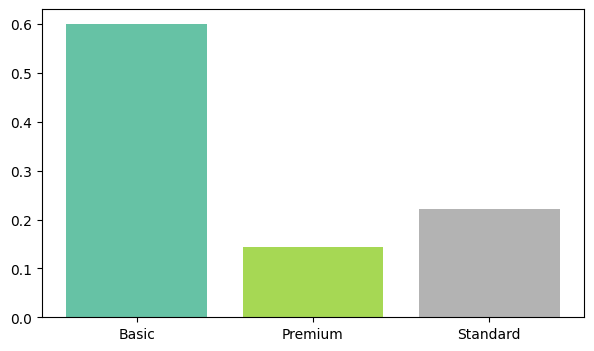

In [75]:
#2 Churn by plan type
churn_plan = df_visual.groupby('plan_type')['churn_flag'].mean()

# colors = ['yellow','purple','blue']
colors = plt.cm.Set2(np.linspace(0,1,len(churn_plan)))

plt.figure(figsize=(7,4))

plt.bar(churn_plan.index,churn_plan.values,color=colors)
plt.show()

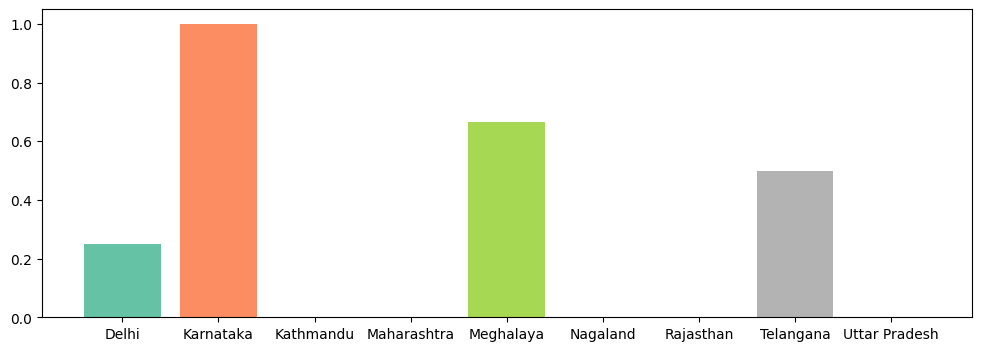

In [76]:
#3 Churn by States

churn_plan = df_visual.groupby('state')['churn_flag'].mean()

# colors = ['yellow','purple','blue']
colors = plt.cm.Set2(np.linspace(0,1,len(churn_plan)))

plt.figure(figsize=(12,4))

plt.bar(churn_plan.index,churn_plan.values,color=colors)
plt.show()

In [87]:
# Data Visualization using Seaborn

In [90]:
#1 encoding - convert str to numeric so that we can find corr between features
df_visual[['plan_type','contract_type','churn_score','churn_flag','churn_risk','escalations']].head()


,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,Standard,Annual,12,0,low,NaN
1,Premium,Annual,91,1,high,Y
2,Basic,Monthly,34,0,low,NaN
3,Premium,Annual,8,0,low,NaN
4,Standard,Monthly,88,1,high,Y


In [91]:
import warnings
warnings.filterwarnings("ignore")

In [92]:
df_encoded = df_visual[['plan_type','contract_type','churn_score','churn_flag','churn_risk','escalations']]

categorial_cols = ['plan_type','contract_type','churn_risk']

for col in categorial_cols:
    df_encoded[col] = df_encoded[col].astype('category').cat.codes

In [ ]:
#2 heatmap (correlation matrix)
sns.heatmap(df_encoded.corr(),annot=True)

In [ ]:
df_visual['plan_type']

In [ ]:
#3 correct method of encoding - based on priority

df_encoded = df_visual[['plan_type','contract_type','churn_score','churn_flag','churn_risk','escalations']]

order_mappings = {
    'plan_type':['Basic','Standard','Premium'],
    'contract_type':['Monthly','Annual'],
    'churn_risk':['low','med','high']}

for col,order in order_mappings.items():
    df_encoded[col] = pd.Categorical(df_encoded[col].astype('category'),categories=order,ordered=True).codes

In [ ]:
 df_encoded.head()

In [ ]:
sns.heatmap(df_encoded.corr(),annot=True)

In [ ]:
#pairplot - relationships in a dataset
sns.pairplot(df_encoded)

In [ ]:
# catplot / facegrid plot - multi-dim comparison

sns.catplot(data=df_visual,
            x='plan_type',
            y='monthly_charges',
            hue='gender',
            col='churn_risk')

In [ ]:
#4 pivot table
pd.pivot_table(
    df_visual,
    values='churn_flag',
    index='plan_type',
    aggfunc='mean'
).reset_index()

In [ ]:
df_visual.columns

In [ ]:
pd.pivot_table(
    df_visual,
    index='plan_type',
    values=['monthly_charges','customerid','churn_flag'],
    aggfunc= {
        'monthly_charges':'sum',
        'customerid':'nunique',
        'churn_flag':'mean'
    }
)

In [ ]:
# Working with in Python (Pandas)

In [ ]:
#1 create db in sql
conn = sqlite3.connect('test_database.sqlite')

#table details
conn.execute("CREATE TABLE users (first_name TEXT,country TEXT,budget INTEGER)")

#commit and save
conn.commit()

In [ ]:
#2 insert data

# write the Sql query to insert records in sql table

cursor = conn.cursor()
cursor.execute(
    """
        INSERT INTO users VALUES
            ('Nishant','India',10000),
            ('Rishabh','Germany',20000),
            ('Farman','Pak',5000)
    """
)

#commit and save

conn.commit()

print("Data inserted successfully")

In [ ]:
#3 check inserted data in table
conn = sqlite3.connect('test_database.sqlite')
query = """SELECT * FROM users"""

df_results = pd.read_sql(query,conn)

df_results.head()

In [ ]:
#4 aggregation
query = """ 
        SELECT country,sum(budget) as total_budget
        FROM users
        GROUP BY country
"""

df_agg = pd.read_sql(query,conn)
df_agg

In [ ]:
#5 always close the conn with db once the task is over
conn.close()